In [ ]:
import pandas as pd
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
import seaborn as sns
import matplotlib.pyplot as plt

g4file = "/mnt/cbib/LNClassifier/paper/nonb-pipeline/results/gencode.v47/transcript_g4Discovery_summary.tsv"

In [ ]:
g4df = pd.read_csv(g4file, sep="\t")
g4df

,transcript_id,transcript_length,coding_class,total_g4Discovery_length,max_g4Discovery_length,g4Discovery_hit_count,g4Discovery_hit_count_per_kb,g4Discovery_coverage,max_g4Discovery_length_as_%
0,ENST00000000233.10,3290,coding,169,40,5,1.519757,5.136778,1.215805
1,ENST00000000412.8,9285,coding,51,29,2,0.215401,0.549273,0.312332
2,ENST00000000442.11,11220,coding,545,50,19,1.693405,4.857398,0.445633
3,ENST00000001008.6,10454,coding,253,34,10,0.956572,2.420126,0.325234
4,ENST00000001146.7,18625,coding,1226,49,42,2.255034,6.582550,0.263087
...,...,...,...,...,...,...,...,...,...
263101,ENST00000850666.1,51930,lncRNA,114,30,5,0.096283,0.219526,0.057770
263102,ENST00000850667.1,25139,lncRNA,144,31,6,0.238673,0.572815,0.123314
263103,ENST00000850668.1,233199,lncRNA,569,40,21,0.090052,0.243998,0.017153
263104,ENST00000850669.1,73927,lncRNA,165,38,6,0.081161,0.223193,0.051402


In [ ]:
g4df.describe()

,transcript_length,total_g4Discovery_length,max_g4Discovery_length,g4Discovery_hit_count,g4Discovery_hit_count_per_kb,g4Discovery_coverage,max_g4Discovery_length_as_%
count,2.631060e+05,263106.000000,263106.000000,263106.000000,263106.000000,263106.000000,263106.000000
mean,5.084846e+04,344.027685,35.630666,12.844880,0.588879,1.616244,0.426138
std,8.923256e+04,565.593752,7.738560,20.877716,0.805379,2.311130,0.815074
min,5.000000e+01,16.000000,16.000000,1.000000,0.008645,0.021894,0.001958
25%,8.011000e+03,73.000000,30.000000,3.000000,0.137832,0.356598,0.063923
50%,2.178500e+04,173.000000,36.000000,6.000000,0.271125,0.706037,0.153816
75%,5.656200e+04,397.000000,41.000000,15.000000,0.694927,1.881574,0.416807
max,2.471657e+06,21576.000000,51.000000,793.000000,20.000000,62.000000,62.000000


In [ ]:
def create_visualization(hits: pd.DataFrame, nbd_type: str) -> None:
    """
    Create multi-panel visualization of NBD metrics using KDE plots.
    
    Args:
        hits: DataFrame with aggregated transcript metrics
        nbd_type: Type of NBD feature being analyzed
    """
    logger.info(f"Creating KDE visualization plots for {nbd_type.upper()}")
    
    # Dynamic column names (now normalized per kb)
    hit_count_col = f'{nbd_type}_hit_count_per_kb'
    max_length_col = f'max_{nbd_type}_length_as_%'
    coverage_col = f'{nbd_type}_coverage'
    nbd_label = nbd_type.upper()
    
    # Set seaborn style for better aesthetics
    sns.set_style("whitegrid")
    
    # Define color palette for consistency
    palette = {'coding': '#1f77b4', 'lncRNA': '#ff7f0e'}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Hit Count Distribution (KDE)
    logger.debug(f"Plotting {nbd_label} hit count KDE distribution")
    for coding_class in sorted(hits['coding_class'].unique()):
        data = hits[hits['coding_class'] == coding_class][hit_count_col]
        sns.kdeplot(data=data, ax=axes[0, 0], clip=(0, None), label=coding_class, 
                   color=palette.get(coding_class), fill=True, alpha=0.3, linewidth=2)
    # Set x-limits to 5th and 95th percentiles
    all_data = hits[hit_count_col]
    axes[0, 0].set_xlim(-1, all_data.quantile(0.99))
    axes[0, 0].set_title(f'{nbd_label} Hit Count per kb', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel(f'{nbd_label} Hit Count / kb', fontsize=10)
    axes[0, 0].set_ylabel('Density', fontsize=10)
    axes[0, 0].legend(title='Coding Class', fontsize=9)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Max NBD Length Distribution (KDE)
    logger.debug(f"Plotting max {nbd_label} length KDE distribution")
    for coding_class in sorted(hits['coding_class'].unique()):
        data = hits[hits['coding_class'] == coding_class][max_length_col]
        sns.kdeplot(data=data, ax=axes[0, 1], cut=0, label=coding_class,
                   color=palette.get(coding_class), fill=True, alpha=0.3, linewidth=2)
    # Set x-limits to 5th and 95th percentiles
    all_data = hits[max_length_col]
    axes[0, 1].set_xlim(-0.1, all_data.quantile(0.99))
    axes[0, 1].set_title(f'Max {nbd_label} Length as coverage of transcript', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel(f'Max {nbd_label} Length coverage (%)', fontsize=10)
    axes[0, 1].set_ylabel('Density', fontsize=10)
    axes[0, 1].legend(title='Coding Class', fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Coverage Distribution (KDE)
    logger.debug(f"Plotting {nbd_label} coverage KDE distribution")
    for coding_class in sorted(hits['coding_class'].unique()):
        data = hits[hits['coding_class'] == coding_class][coverage_col]
        sns.kdeplot(data=data, ax=axes[1, 0], label=coding_class,
                   color=palette.get(coding_class), fill=True, alpha=0.3, linewidth=2)
    # Set x-limits to 5th and 95th percentiles
    all_data = hits[coverage_col]
    axes[1, 0].set_xlim(-0.1, all_data.quantile(0.99))
    axes[1, 0].set_title(f'{nbd_label} Coverage', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel(f'{nbd_label} Coverage (%)', fontsize=10)
    axes[1, 0].set_ylabel('Density', fontsize=10)
    axes[1, 0].legend(title='Coding Class', fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Transcript Length Distribution (KDE)
    logger.debug("Plotting transcript length KDE distribution")
    for coding_class in sorted(hits['coding_class'].unique()):
        data = hits[hits['coding_class'] == coding_class]['transcript_length']
        sns.kdeplot(data=data, ax=axes[1, 1], label=coding_class,
                   color=palette.get(coding_class), fill=True, alpha=0.3, linewidth=2)
    # Set x-limits to 5th and 95th percentiles
    all_data = hits['transcript_length']
    axes[1, 1].set_xlim(-0.1, all_data.quantile(0.99))
    axes[1, 1].set_title('Transcript Length Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Transcript Length (bp)', fontsize=10)
    axes[1, 1].set_ylabel('Density', fontsize=10)
    axes[1, 1].legend(title='Coding Class', fontsize=9)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()


def create_visualization_other(hits: pd.DataFrame, nbd_type: str) -> None:
    """
    Create multi-panel visualization of NBD metrics using histograms and ECDFs.
    
    Args:
        hits: DataFrame with aggregated transcript metrics
        nbd_type: Type of NBD feature being analyzed
    """
    logger.info(f"Creating visualization plots for {nbd_type.upper()}")
    
    # Dynamic column names
    hit_count_col = f'{nbd_type}_hit_count_per_kb'
    max_length_col = f'max_{nbd_type}_length_as_%'
    coverage_col = f'{nbd_type}_coverage'
    nbd_label = nbd_type.upper()
    
    sns.set_style("whitegrid")
    palette = {'coding': '#1f77b4', 'lncRNA': '#ff7f0e'}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Hit Count Distribution (Histogram)
    logger.debug(f"Plotting {nbd_label} hit count histogram")
    sns.histplot(data=hits, x=hit_count_col, hue='coding_class',
                 ax=axes[0, 0], bins=100, alpha=0.6, stat='density',
                 palette=palette, common_norm=False)
    all_data = hits[hit_count_col]
    axes[0, 0].set_xlim(0, all_data.quantile(0.99))
    axes[0, 0].set_title(f'{nbd_label} Hit Count per kb', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel(f'{nbd_label} Hit Count / kb', fontsize=10)
    axes[0, 0].set_ylabel('Density', fontsize=10)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    axes[0, 0].legend(handles, ['Coding', 'lncRNA'], title='Coding Class', fontsize=9)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Max NBD Length ECDF
    logger.debug(f"Plotting max {nbd_label} length ECDF")
    sns.ecdfplot(data=hits, x=max_length_col, hue='coding_class',
                 ax=axes[0, 1], palette=palette, linewidth=2.5)
    all_data = hits[max_length_col]
    axes[0, 1].set_xlim(0, all_data.quantile(0.99))
    axes[0, 1].set_title(f'Max {nbd_label} Length - Cumulative Distribution', 
                        fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel(f'Max {nbd_label} Length coverage (%)', fontsize=10)
    axes[0, 1].set_ylabel('Cumulative Proportion', fontsize=10)
    handles, labels = axes[0, 1].get_legend_handles_labels()
    axes[0, 1].legend(handles, ['Coding', 'lncRNA'], title='Coding Class', fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Coverage Distribution (Histogram)
    logger.debug(f"Plotting {nbd_label} coverage histogram")
    sns.histplot(data=hits, x=coverage_col, hue='coding_class',
                 ax=axes[1, 0], bins=100, alpha=0.6, stat='density',
                 palette=palette, common_norm=False)
    all_data = hits[coverage_col]
    axes[1, 0].set_xlim(0, all_data.quantile(0.99))
    axes[1, 0].set_title(f'{nbd_label} Coverage', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel(f'{nbd_label} Coverage (%)', fontsize=10)
    axes[1, 0].set_ylabel('Density', fontsize=10)
    handles, labels = axes[1, 0].get_legend_handles_labels()
    axes[1, 0].legend(handles, ['Coding', 'lncRNA'], title='Coding Class', fontsize=9)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Transcript Length ECDF
    logger.debug("Plotting transcript length ECDF")
    sns.ecdfplot(data=hits, x='transcript_length', hue='coding_class',
                 ax=axes[1, 1], palette=palette, linewidth=2.5)
    all_data = hits['transcript_length']
    axes[1, 1].set_xlim(0, all_data.quantile(0.99))
    axes[1, 1].set_title('Transcript Length - Cumulative Distribution', 
                        fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Transcript Length (bp)', fontsize=10)
    axes[1, 1].set_ylabel('Cumulative Proportion', fontsize=10)
    handles, labels = axes[1, 1].get_legend_handles_labels()
    axes[1, 1].legend(handles, ['Coding', 'lncRNA'], title='Coding Class', fontsize=9)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

2026-02-06 18:55:52,937 - INFO - Creating KDE visualization plots for G4DISCOVERY


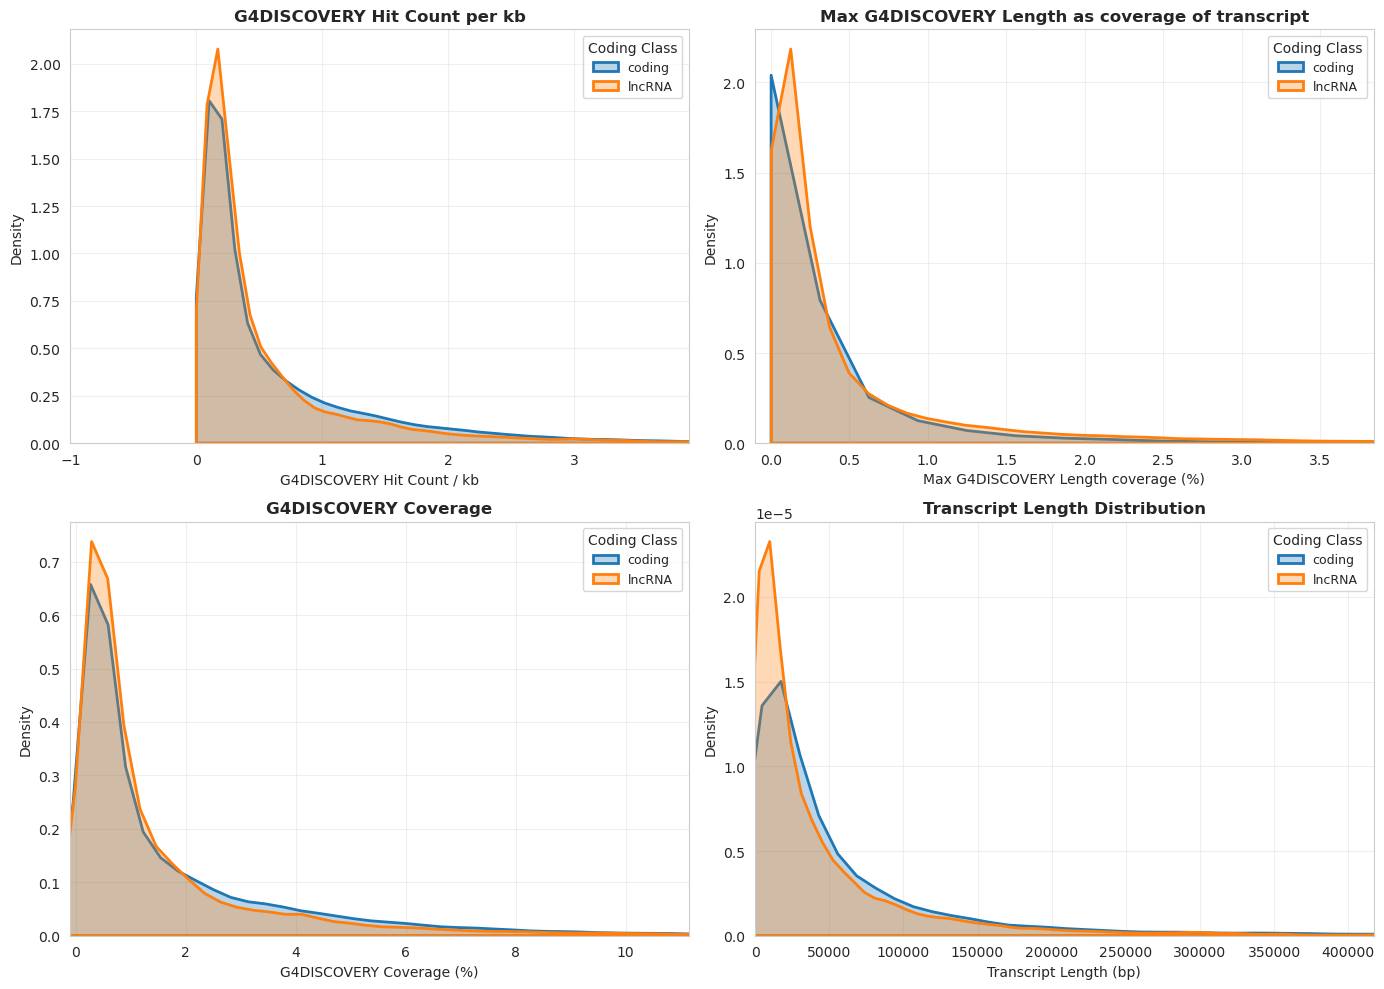

In [ ]:
create_visualization(g4df, nbd_type="g4Discovery")

2026-02-06 18:56:00,371 - INFO - Creating visualization plots for G4DISCOVERY


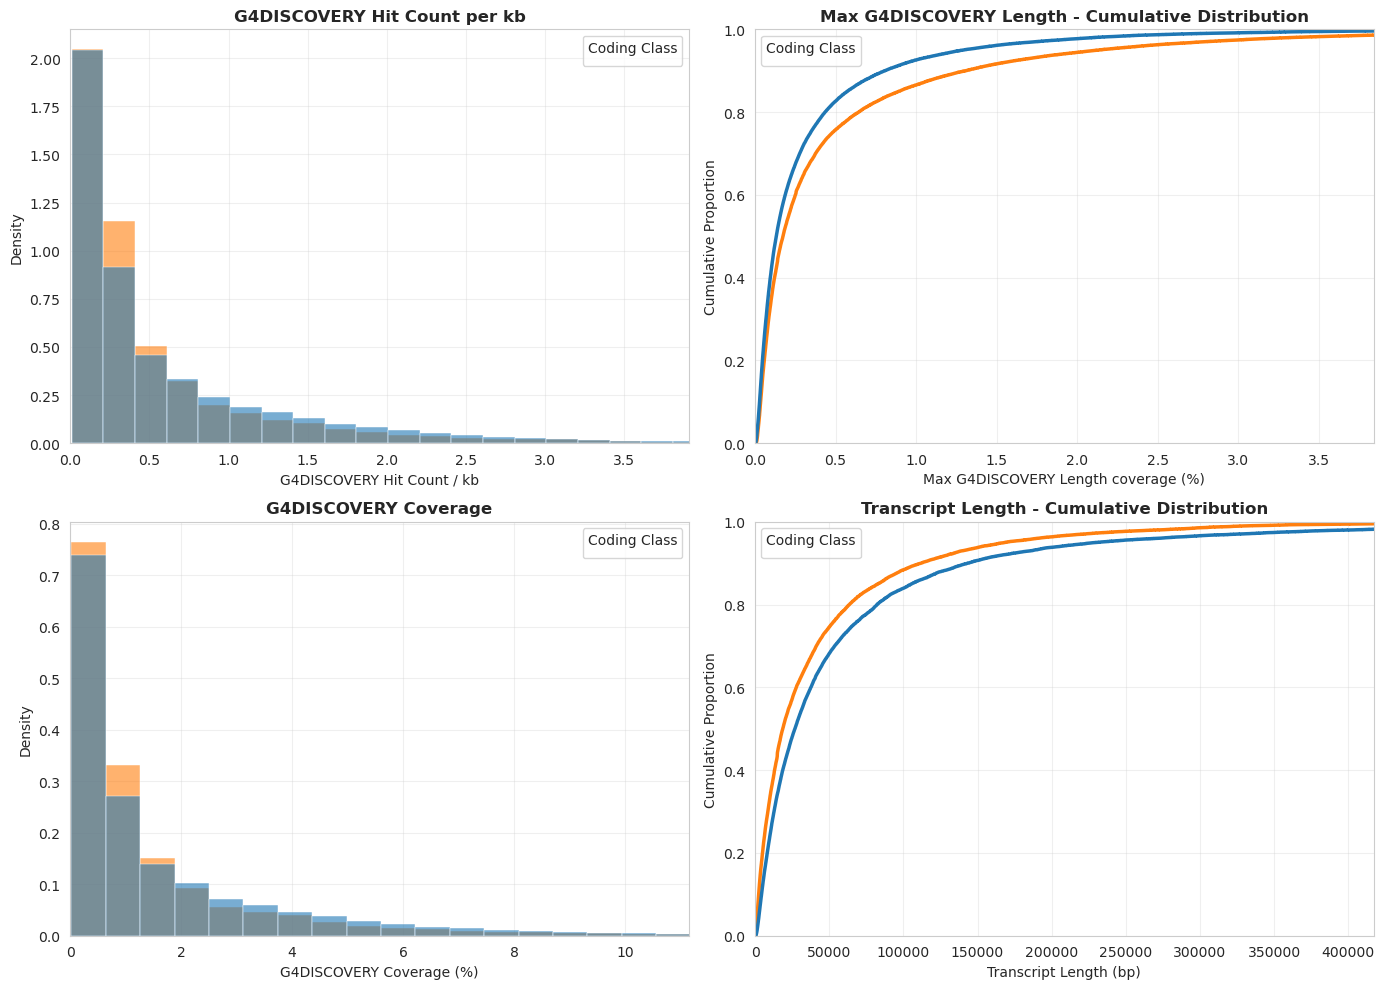

In [ ]:
create_visualization_other(g4df, nbd_type="g4Discovery")

2026-02-06 18:56:04,022 - INFO - Creating visualization plots for G4DISCOVERY


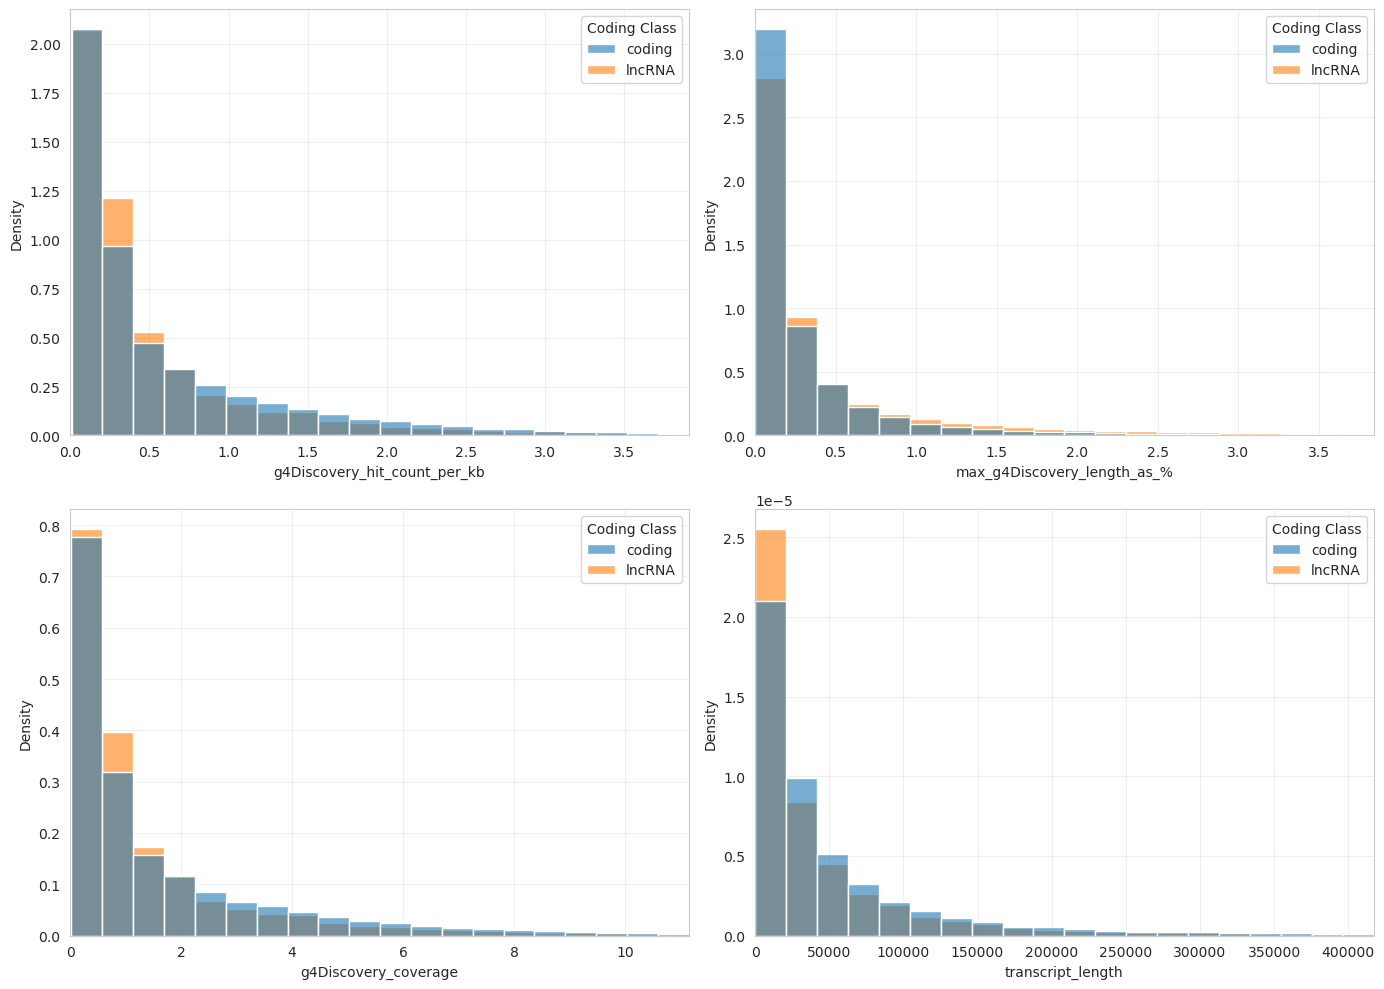

In [ ]:
def create_visualization_simple(hits: pd.DataFrame, nbd_type: str) -> None:
    """
    Create multi-panel visualization of NBD metrics using histograms and ECDFs.
    
    Args:
        hits: DataFrame with aggregated transcript metrics
        nbd_type: Type of NBD feature being analyzed
    """
    logger.info(f"Creating visualization plots for {nbd_type.upper()}")
    
    # Dynamic column names
    hit_count_col = f'{nbd_type}_hit_count_per_kb'
    max_length_col = f'max_{nbd_type}_length_as_%'
    coverage_col = f'{nbd_type}_coverage'
    nbd_label = nbd_type.upper()
    
    sns.set_style("whitegrid")
    palette = {'coding': '#1f77b4', 'lncRNA': '#ff7f0e'}
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for ax, col in zip(axes.flatten(), [hit_count_col, max_length_col, coverage_col, 'transcript_length']):
        p99 = hits[col].quantile(0.99)
        s = sns.histplot(data=hits, x=col, hue='coding_class',
                ax=ax, bins=20, binrange=(hits[col].min(), p99), alpha=0.6, stat='density',
                palette=palette, common_norm=False)
        
        s.legend_.set_title('Coding Class')
        ax.set_xlim(0, p99)
        ax.grid(True, alpha=0.3)
        #handles, labels = ax.get_legend_handles_labels()
        #ax.legend(handles, labels, title='Coding Class', fontsize=9)
    plt.tight_layout()
    plt.show()

create_visualization_simple(g4df, nbd_type="g4Discovery")

In [ ]:
g4df.loc[g4df['coding_class'] == 'lncRNA', 'transcript_length'].describe()

count    1.585940e+05
mean     4.360680e+04
std      6.812429e+04
min      1.270000e+02
25%      6.613000e+03
50%      1.864600e+04
75%      5.089075e+04
max      1.375317e+06
Name: transcript_length, dtype: float64